<h1>1. Load Data</h1>

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from pathlib import Path
from shapely.geometry import Point
from matplotlib.patches import Patch

In [2]:
base_dir = Path("..")

base_dir.mkdir(parents=True, exist_ok=True)

# file polygon
grid_path = base_dir / "data" / "raw" / "map" / "jakarta_grid_polygon_1km.geojson"

#file hasil prediksi
#pred_path = base_dir / "data" / "processed" / "predicted_label_no_modis_2023.csv" #done
#pred_path = base_dir / "data" / "processed" / "predicted_label_no_modis_2024.csv" #done
pred_path = base_dir / "data" / "processed" / "predicted_label_no_modis_2025.csv"

#file output
output_path = base_dir / "outputs"
#out_path = output_path / "Peta_Jakarta_1KM_2023.png"
#out_path = output_path / "Peta_Jakarta_1KM_2024.png"
out_path = output_path / "Peta_Jakarta_1KM_2025.png"


<h2>1.1 Load Polygon</h2>

In [3]:
gdf_grid = gpd.read_file(grid_path)

print("Grid shape:", gdf_grid.shape)
print("Grid columns:", gdf_grid.columns.tolist())
print("Grid CRS:", gdf_grid.crs)
gdf_grid.head()

Grid shape: (737, 3)
Grid columns: ['id', 'grid_id', 'geometry']
Grid CRS: EPSG:4326


,id,grid_id,geometry
0,0,grid_001,"POLYGON ((106.88948 -6.36865, 106.88947 -6.365..."
1,1,grid_002,"POLYGON ((106.89852 -6.3699, 106.8985 -6.36556..."
2,2,grid_003,"POLYGON ((106.90261 -6.36554, 106.8985 -6.3655..."
3,3,grid_004,"POLYGON ((106.91652 -6.36549, 106.91406 -6.365..."
4,4,grid_005,"POLYGON ((106.79909 -6.3643, 106.79906 -6.3568..."


<h4>1.2 Load Label Prediksi</h4>

In [4]:
df_pred = pd.read_csv(pred_path)

print("Pred shape:", df_pred.shape)
print("Pred columns:", df_pred.columns.tolist())
df_pred.head()


Pred shape: (658, 4)
Pred columns: ['lat', 'lon', 'predicted_class', 'predicted_label']


,lat,lon,predicted_class,predicted_label
0,-6.364564,106.886044,2,UNHEALTHY
1,-6.364564,106.895027,1,MEDIUM
2,-6.364564,106.912994,2,UNHEALTHY
3,-6.355581,106.796213,2,UNHEALTHY
4,-6.355581,106.805196,1,MEDIUM


<h4> 1.3 ubah prediksi menjadi GeoDataFrame Point</h4>

In [5]:
# pastikan tipe numerik
df_pred["lat"] = pd.to_numeric(df_pred["lat"], errors="coerce")
df_pred["lon"] = pd.to_numeric(df_pred["lon"], errors="coerce")

# drop baris lat lon yg kosong jika ad
df_pred = df_pred.dropna(subset=["lat", "lon"]).copy()

# geometry pointnya
geometry = [Point(xy) for xy in zip(df_pred["lon"], df_pred["lat"])]

gdf_pred = gpd.GeoDataFrame(
    df_pred,
    geometry=geometry,
    crs="EPSG:4326"
)

print("Pred Geo shape:", gdf_pred.shape)
print("Pred Geo CRS:", gdf_pred.crs)
gdf_pred.head()


Pred Geo shape: (658, 5)
Pred Geo CRS: EPSG:4326


,lat,lon,predicted_class,predicted_label,geometry
0,-6.364564,106.886044,2,UNHEALTHY,POINT (106.88604 -6.36456)
1,-6.364564,106.895027,1,MEDIUM,POINT (106.89503 -6.36456)
2,-6.364564,106.912994,2,UNHEALTHY,POINT (106.91299 -6.36456)
3,-6.355581,106.796213,2,UNHEALTHY,POINT (106.79621 -6.35558)
4,-6.355581,106.805196,1,MEDIUM,POINT (106.8052 -6.35558)


In [6]:
# Samakan CRS Grid ke EPSG : 4326
if gdf_grid.crs is None:
    gdf_grid = gdf_grid.set_crs("EPSG:4326")

if gdf_grid.crs.to_string() != "EPSG:4326":
    gdf_grid = gdf_grid.to_crs("EPSG:4326")

print("Grid CRS (after):", gdf_grid.crs)

Grid CRS (after): EPSG:4326


In [7]:
print("Grid bounds:", gdf_grid.total_bounds) 
print("Pred bounds:", gdf_pred.total_bounds)


Grid bounds: [106.68499182  -6.37134208 106.97303962  -6.07611855]
Pred bounds: [106.68841472  -6.36456379 106.96689246  -6.0771029 ]


<h2>2. Pembuatan Peta</h2>

In [8]:
# spasial join seluruh prediksi -> gird
joined_all = gpd.sjoin(
    gdf_pred,       
    gdf_grid[["grid_id", "geometry"]],
    how="left",
    predicate="within"
)

print("Joined all:", joined_all.shape)
print("Missing grid_id:", joined_all["grid_id"].isna().sum())

Joined all: (658, 7)
Missing grid_id: 0


<h4>2.1 Agregasi rata-rata per grid</h4>

In [9]:
# grid_agg = (
#     joined_all.dropna(subset=["grid_id"])
#     .groupby("grid_id")["predicted_class"]
#     .mean()
#     .reset_index()
#     .rename(columns={"predicted_class": "mean_pred"})
# )
grid_agg = (
    joined_all.dropna(subset=["grid_id"])
    .groupby("grid_id")["predicted_class"]
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    .reset_index()
    .rename(columns={"predicted_class": "agg_class"})
)


print(grid_agg.head())
print("Grid with mean:", grid_agg.shape[0])


    grid_id  agg_class
0  grid_012          2
1  grid_013          1
2  grid_015          2
3  grid_017          2
4  grid_018          1
Grid with mean: 630


In [10]:
#Merge ke polygon grid
gdf_grid_agg = gdf_grid.merge(grid_agg, on="grid_id", how="left")
print("Grid total:", len(gdf_grid_agg))
print("Grid without mean_pred:", gdf_grid_agg["agg_class"].isna().sum())


Grid total: 737
Grid without mean_pred: 107


<h4>2.2 Isi NaN dengan grid terdekat</h4>

In [11]:
# isi NaN dengan grid terdekat
gdf_has = gdf_grid_agg[gdf_grid_agg["agg_class"].notna()].copy()
gdf_miss = gdf_grid_agg[gdf_grid_agg["agg_class"].isna()].copy()

print("Has:", len(gdf_has), "Missing:", len(gdf_miss))

if len(gdf_miss) > 0:
    gdf_has_m = gdf_has.to_crs("EPSG:32748")
    gdf_miss_m = gdf_miss.to_crs("EPSG:32748")

    gdf_has_m["geometry"] = gdf_has_m.geometry.centroid
    gdf_miss_m["geometry"] = gdf_miss_m.geometry.centroid

    nearest = gpd.sjoin_nearest(
        gdf_miss_m[["grid_id", "geometry"]],
        gdf_has_m[["grid_id", "agg_class", "geometry"]],
        how="left",
        distance_col="dist_m"
    )

    mean_cols = [c for c in nearest.columns if "agg_class" in c]
    if len(mean_cols) != 1:
        raise ValueError(f"Kolom mean_pred tidak unik / tidak ketemu. Kolom yang ada: {nearest.columns.tolist()}")

    mean_col = mean_cols[0]
    print("Using mean column:", mean_col)

    # grid kosong -> mean_pred terdekat
    fill_df = nearest[["grid_id_left", mean_col]].rename(
        columns={"grid_id_left": "grid_id", mean_col: "agg_class_nn"}
    )

    # Merge kembali ke poly
    gdf_grid_agg = gdf_grid_agg.merge(fill_df, on="grid_id", how="left")
    gdf_grid_agg["agg_class"] = gdf_grid_agg["agg_class"].fillna(gdf_grid_agg["agg_class_nn"])
    gdf_grid_agg = gdf_grid_agg.drop(columns=["agg_class_nn"])

print("Remaining NaN agg_class:", gdf_grid_agg["agg_class"].isna().sum())


Has: 630 Missing: 107
Using mean column: agg_class
Remaining NaN agg_class: 0


<h4>2.3 Mapping 3 kelas</h4>

In [12]:
def mean_to_label(x):
    if x < 0.5:
        return "GOOD"
    elif x < 1.5:
        return "MEDIUM"
    else:
        return "UNHEALTHY"

gdf_grid_agg["agg_label"] = gdf_grid_agg["agg_class"].apply(mean_to_label)
print(gdf_grid_agg["agg_label"].value_counts())


agg_label
MEDIUM       460
UNHEALTHY    164
GOOD         113
Name: count, dtype: int64


<h2>3. Load Map Tambahan</h2>

In [13]:
import geopandas as gpd

gadm_path = Path("../data/raw/map/gadm41_IDN_2.json")

gdf_gadm = gpd.read_file(gadm_path)
print("GADM shape:", gdf_gadm.shape)
print("GADM CRS:", gdf_gadm.crs)
print("GADM columns:", gdf_gadm.columns.tolist())
gdf_gadm.head()


GADM shape: (502, 14)
GADM CRS: EPSG:4326
GADM columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']


,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,IDN.1.2_1,IDN,Indonesia,IDN.1_1,Aceh,NA,AcehBarat,NA,NA,Kabupaten,Regency,1107,ID.AC.AB,"MULTIPOLYGON (((96.0691 4.1954, 96.0554 4.2052..."
1,IDN.1.1_1,IDN,Indonesia,IDN.1_1,Aceh,NA,AcehBaratDaya,NA,NA,Kabupaten,Regency,1112,ID.AC.AD,"MULTIPOLYGON (((96.942 3.5746, 96.9343 3.5782,..."
2,IDN.1.3_1,IDN,Indonesia,IDN.1_1,Aceh,NA,AcehBesar,NA,NA,Kabupaten,Regency,1108,ID.AC.AR,"MULTIPOLYGON (((95.2037 5.3128, 95.2034 5.3127..."
3,IDN.1.4_1,IDN,Indonesia,IDN.1_1,Aceh,NA,AcehJaya,NA,NA,Kabupaten,Regency,1116,ID.AC.AJ,"MULTIPOLYGON (((95.8767 4.3675, 95.8769 4.3675..."
4,IDN.1.5_1,IDN,Indonesia,IDN.1_1,Aceh,NA,AcehSelatan,NA,NA,Kabupaten,Regency,1103,ID.AC.AS,"MULTIPOLYGON (((97.7469 2.44, 97.7321 2.4227, ..."


<h4>3.1 Filter 5 wilayah Jakarta</h4>

In [14]:
if gdf_gadm.crs is None:
    gdf_gadm = gdf_gadm.set_crs("EPSG:4326")
else:
    gdf_gadm = gdf_gadm.to_crs("EPSG:4326")

target_cities = {
    "JakartaBarat",
    "JakartaPusat",
    "JakartaSelatan",
    "JakartaTimur",
    "JakartaUtara",
}

#Filter DKI 5 kota
gdf_admin = gdf_gadm[
    (gdf_gadm["NAME_1"] == "JakartaRaya") &
    (gdf_gadm["NAME_2"].isin(target_cities))
].copy()

print("Admin (5 kota) shape:", gdf_admin.shape)
print(gdf_admin["NAME_2"].value_counts())
gdf_admin[["NAME_1", "NAME_2"]].head()


Admin (5 kota) shape: (5, 14)
NAME_2
JakartaBarat      1
JakartaPusat      1
JakartaSelatan    1
JakartaTimur      1
JakartaUtara      1
Name: count, dtype: int64


,NAME_1,NAME_2
64,JakartaRaya,JakartaBarat
65,JakartaRaya,JakartaPusat
66,JakartaRaya,JakartaSelatan
67,JakartaRaya,JakartaTimur
68,JakartaRaya,JakartaUtara


<h4>3.3 Batas Wilayah hanya di grid</h4>

In [15]:
aoi_union = gdf_grid_agg.geometry.union_all()
gdf_admin = gdf_admin.copy()
gdf_admin["geometry"] = gdf_admin.geometry.intersection(aoi_union)


<h2>4. Mapping Proses</h2>
<h4>4.1 Prepare Layer</h4>

In [16]:
#Color Maping
label_colors = {
    "GOOD": "#2ca25f",
    "MEDIUM": "#fdae61",
    "UNHEALTHY": "#d73027"
}

# Warna grid
gdf_plot = gdf_grid_agg.copy()
gdf_plot["color"] = gdf_plot["agg_label"].map(label_colors)

#Clean admin geometry
gdf_admin_clean = gdf_admin.copy()
gdf_admin_clean = gdf_admin_clean[gdf_admin_clean.geometry.notna()].copy()
gdf_admin_clean = gdf_admin_clean[~gdf_admin_clean.geometry.is_empty].copy()
gdf_admin_clean["geometry"] = gdf_admin_clean["geometry"].buffer(0)

#Pastikan CRS
if gdf_plot.crs is None:
    gdf_plot = gdf_plot.set_crs("EPSG:4326")
if gdf_admin_clean.crs is None:
    gdf_admin_clean = gdf_admin_clean.set_crs("EPSG:4326")

#Samakan CRS admin ke CRS grid
gdf_admin_clean = gdf_admin_clean.to_crs(gdf_plot.crs)



<h4>4.2 Clip grid batas wilayah</h4>

In [18]:
#Boundary Jakarta (union)
jakarta_boundary = gdf_admin_clean.geometry.union_all()
gdf_mask = gpd.GeoDataFrame(geometry=[jakarta_boundary], crs=gdf_plot.crs)

# Clip grid
gdf_plot_clip = gpd.clip(gdf_plot, gdf_mask)
gdf_plot_clip = gdf_plot_clip[gdf_plot_clip.geometry.notna()].copy()
gdf_plot_clip = gdf_plot_clip[~gdf_plot_clip.geometry.is_empty].copy()

# Legend kelas
legend_elements = [
    Patch(facecolor=label_colors["GOOD"], edgecolor="white", label="GOOD"),
    Patch(facecolor=label_colors["MEDIUM"], edgecolor="white", label="MEDIUM"),
    Patch(facecolor=label_colors["UNHEALTHY"], edgecolor="white", label="UNHEALTHY"),
]


<h4>4.3 Plot base map (choropleth map)</h4>

In [19]:
print(sorted(gdf_admin_clean["NAME_2"].unique()))

['JakartaBarat', 'JakartaPusat', 'JakartaSelatan', 'JakartaTimur', 'JakartaUtara']


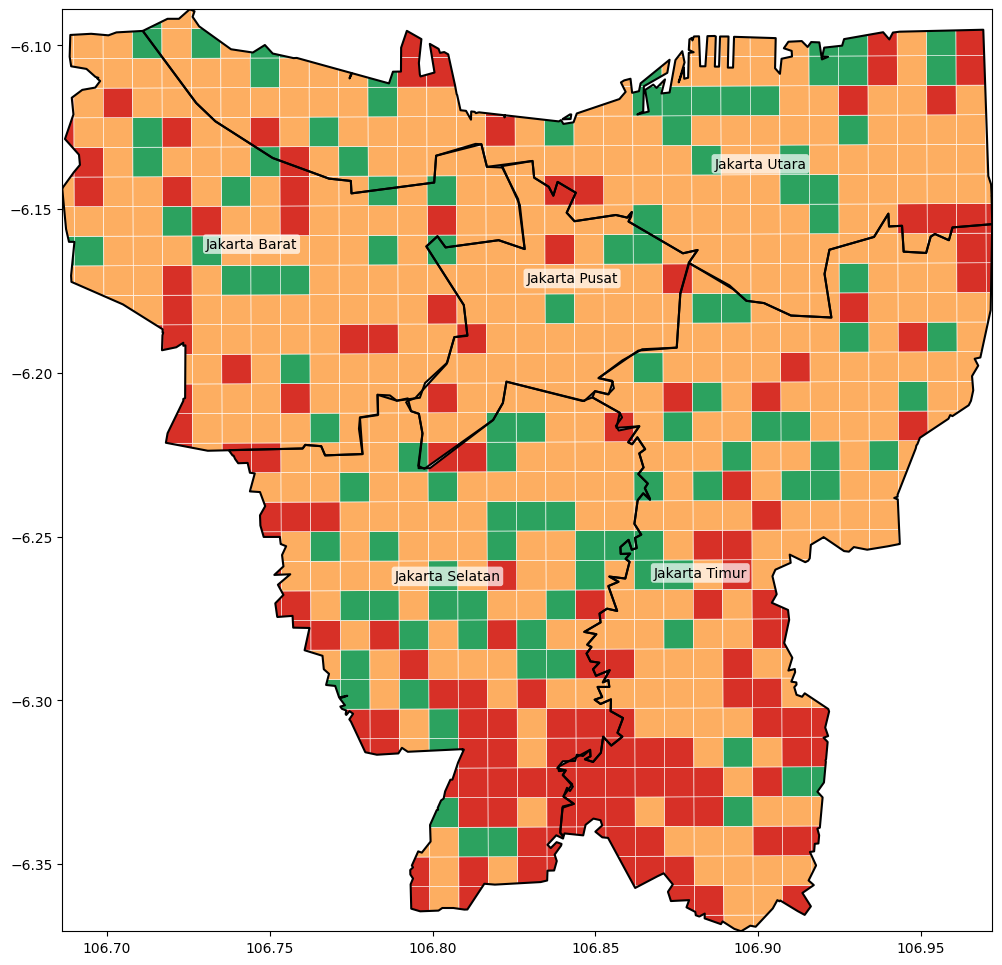

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Choropleth grid
gdf_plot_clip.plot(
    ax=ax,
    color=gdf_plot_clip["color"],
    edgecolor="white",
    linewidth=0.4,
    zorder=1
)

# set extent
minx, miny, maxx, maxy = gdf_plot_clip.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

# Batas wilayah
gdf_admin_clean.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5,
    zorder=5
)

def pretty_city(name: str) -> str:
    # dari "JakartaSelatan" -> "Jakarta Selatan"
    return name.replace("Jakarta", "Jakarta ")

city_offsets_points = {
    "JakartaSelatan": (0, 50),
    "JakartaPusat": (0, 30)
}
for _, row in gdf_admin_clean.iterrows():
    rp = row.geometry.representative_point()
    name_key = row["NAME_2"]
    city_name = pretty_city(name_key)
    dxp, dyp = city_offsets_points.get(name_key, (0, 0))
    
    ax.annotate(
        city_name,
        xy=(rp.x, rp.y),
        xytext=(dxp, dyp),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=10,
        color="black",
        zorder=6,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

<h4>4.4 Titik 8 Station Ground-Bas</h4>

In [21]:
stations = {
    "Bundaran Hotel Indonesia": (-6.19492, 106.82347),
    "Jagakarsa": (-6.33539, 106.82558),
    "Jalan BDN II": (-6.28285, 106.79946),
    "Kebon Jeruk": (-6.19678, 106.76886),
    "Kelapa Gading": (-6.16128, 106.90499),
    "Komp Angkasa Pura": (-6.15140, 106.83999),
    "Lubang Buaya": (-6.29723, 106.90286),
    "US Consulate": (-6.18082, 106.83015),
}

df_st = pd.DataFrame(
    [{"station": k, "lat": v[0], "lon": v[1]} for k, v in stations.items()]
)

gdf_st = gpd.GeoDataFrame(
    df_st,
    geometry=[Point(xy) for xy in zip(df_st["lon"], df_st["lat"])],
    crs="EPSG:4326"
).to_crs(gdf_plot_clip.crs)

# Plot titik station
gdf_st.plot(
    ax=ax,
    marker="o",
    markersize=55,
    edgecolor="black",
    linewidth=1.0,
    alpha=1.0,
    zorder=12
)

# Label station
for _, r in gdf_st.iterrows():
    ax.annotate(
        r["station"],
        xy=(r.geometry.x, r.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        zorder=13,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7)
    )

# Handle legend station
station_handle = mlines.Line2D(
    [], [], color="blue", marker="o", linestyle="None",
    markersize=7, label="Ground Stations"
)


<h4>4.5 Show + save</h4>

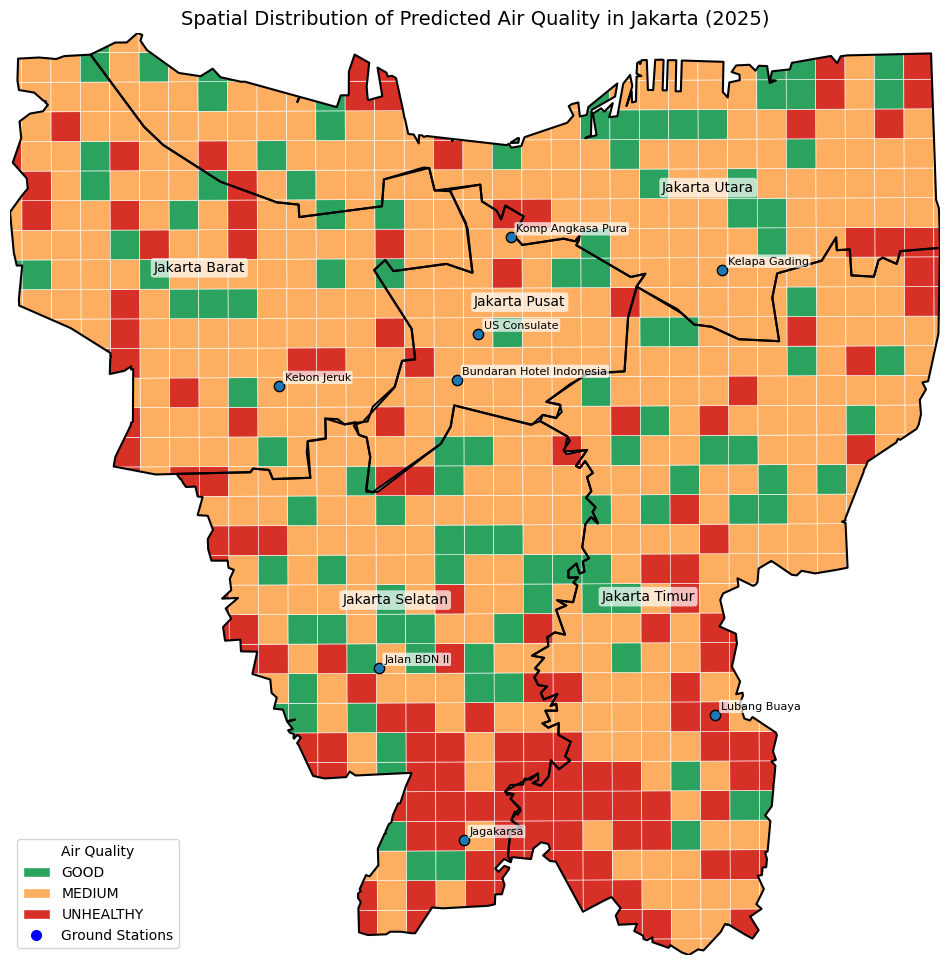

Saved: C:\Users\USER\Project-3-air-quality-classification\outputs\Peta_Jakarta_1KM_2025.png


In [22]:
from IPython.display import display

ax.set_title("Spatial Distribution of Predicted Air Quality in Jakarta (2025)", fontsize=14)
ax.set_axis_off()

ax.legend(
    handles=legend_elements + [station_handle],
    loc="lower left",
    frameon=True,
    title="Air Quality"
)

fig.savefig(out_path, dpi=300, bbox_inches="tight")

display(fig)
plt.close(fig)

print("Saved:", out_path.resolve())
